In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Data ---
print("--- 1. Loading Data ---")
RECEIVALS_FILE = "data/kernel/receivals.csv"
PURCHASE_ORDERS_FILE = "data/kernel/purchase_orders.csv"

try:
    df_receivals = pd.read_csv(RECEIVALS_FILE)
    df_po = pd.read_csv(PURCHASE_ORDERS_FILE)
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: Files not found. Make sure paths are correct.")
    # Stop execution if files aren't found
    raise

# --- 2. Perform All Cleaning Steps ---
print("\n--- 2. Cleaning Data ---")

# Convert receivals date_arrival to UTC
df_receivals['date_arrival'] = pd.to_datetime(df_receivals['date_arrival'], utc=True, errors='coerce')

# Convert po dates to UTC
df_po['delivery_date'] = pd.to_datetime(df_po['delivery_date'], errors='coerce', utc=True)
df_po['created_date_time'] = pd.to_datetime(df_po['created_date_time'], errors='coerce', utc=True)
df_po['modified_date_time'] = pd.to_datetime(df_po['modified_date_time'], errors='coerce', utc=True)

# Clean df_receivals (drop NaNs, drop net_weight <= 0)
initial_receivals_count = len(df_receivals)
df_receivals_cleaned = df_receivals.dropna(
    subset=['rm_id', 'product_id', 'purchase_order_id', 'net_weight']
).copy()
df_receivals_cleaned = df_receivals_cleaned[df_receivals_cleaned['net_weight'] > 0].copy()
final_receivals_count = len(df_receivals_cleaned)
print(f"Cleaned df_receivals: Dropped {initial_receivals_count - final_receivals_count} rows.")

# Clean df_po (drop NaNs, filter for 'KG', drop quantity <= 0)
initial_po_count = len(df_po)
df_po_cleaned = df_po.dropna(subset=['unit_id', 'unit']).copy()
df_po_cleaned = df_po_cleaned[df_po_cleaned['unit'] == 'KG'].copy()
df_po_cleaned = df_po_cleaned[df_po_cleaned['quantity'] > 0].copy()
final_po_count = len(df_po_cleaned)
print(f"Cleaned df_po: Dropped {initial_po_count - final_po_count} rows.")

# --- 3. Create Validation Split ---
print("\n--- 3. Creating Validation Split ---")
VALIDATION_START_DATE = pd.to_datetime('2024-08-01', utc=True)

train_receivals = df_receivals_cleaned[df_receivals_cleaned['date_arrival'] < VALIDATION_START_DATE].copy()
validation_receivals = df_receivals_cleaned[df_receivals_cleaned['date_arrival'] >= VALIDATION_START_DATE].copy()

print("Training and validation sets created.")
print(f"Total cleaned receivals:  {len(df_receivals_cleaned)}")
print(f"Training receivals:       {len(train_receivals)}")
print(f"Validation receivals:     {len(validation_receivals)}")

print("\n--- Setup Complete ---")

--- 1. Loading Data ---
Data loaded successfully.

--- 2. Cleaning Data ---
Cleaned df_receivals: Dropped 207 rows.
Cleaned df_po: Dropped 58 rows.

--- 3. Creating Validation Split ---
Training and validation sets created.
Total cleaned receivals:  122383
Training receivals:       120268
Validation receivals:     2115

--- Setup Complete ---


# Phase 2a: Anomaly Cleaning and Distribution EDA

The `.describe()` output from the previous step revealed serious data quality issues, particularly in the `quantity` column (negative values and massive outliers) and in the `net_weight` column (0 values).

Our first step in feature engineering is to clean this data, as these anomalies will make any model unstable.

1.  **Investigate:** We will count how many rows have these problematic `net_weight <= 0` or `quantity <= 0` values.
2.  **Clean:** We will filter both `df_receivals_cleaned` and `df_po_cleaned` to *only* include rows where `net_weight > 0` and `quantity > 0`, respectively.
3.  **Re-split:** We must re-create our `train_receivals` and `validation_receivals` sets from the newly cleaned `df_receivals_cleaned`.
4.  **Visualize:** We will create histograms to visualize the distributions of our key numeric columns (`net_weight`, `quantity`) *after* cleaning. This will show us how skewed the data is and whether we'll need to use transformations (like a log transform).

--- 1. Investigating 0 or negative values ---
Found 0 POs with quantity <= 0.
Found 0 receivals with net_weight <= 0.

--- 2. Cleaning 0/negative values ---
New df_po_cleaned shape (quantity > 0): (33113, 12)
New df_receivals_cleaned shape (net_weight > 0): (122383, 10)

--- 3. Re-splitting receivals data (Post-Cleaning) ---
Total cleaned receivals:  122383
New training receivals:       120268
New validation receivals:     2115
Check: Is total == train + val?  True

--- 4. Visualizing Distributions (Post-Cleaning) ---
Saved 'distributions_cleaned.png'

--- 5. Visualizing Log-Transformed Distributions ---
Saved 'log_distributions_cleaned.png'

EDA on anomalies and distributions complete.


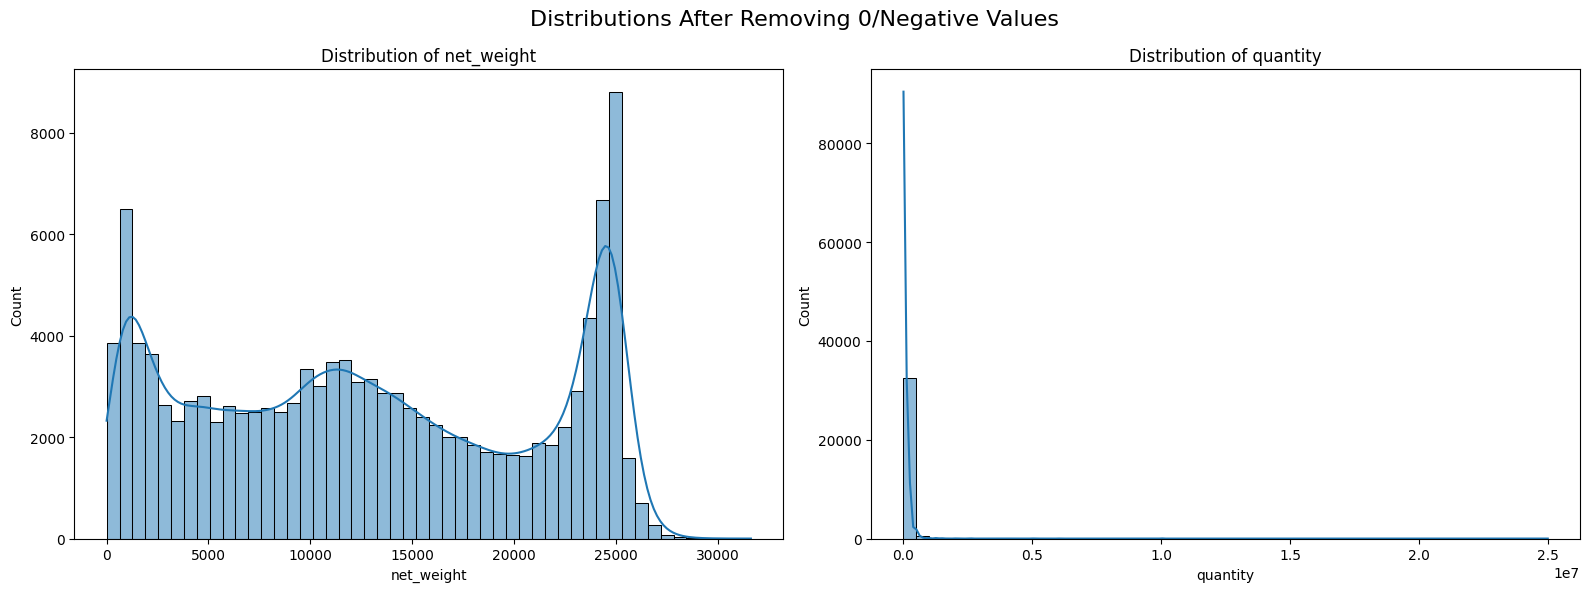

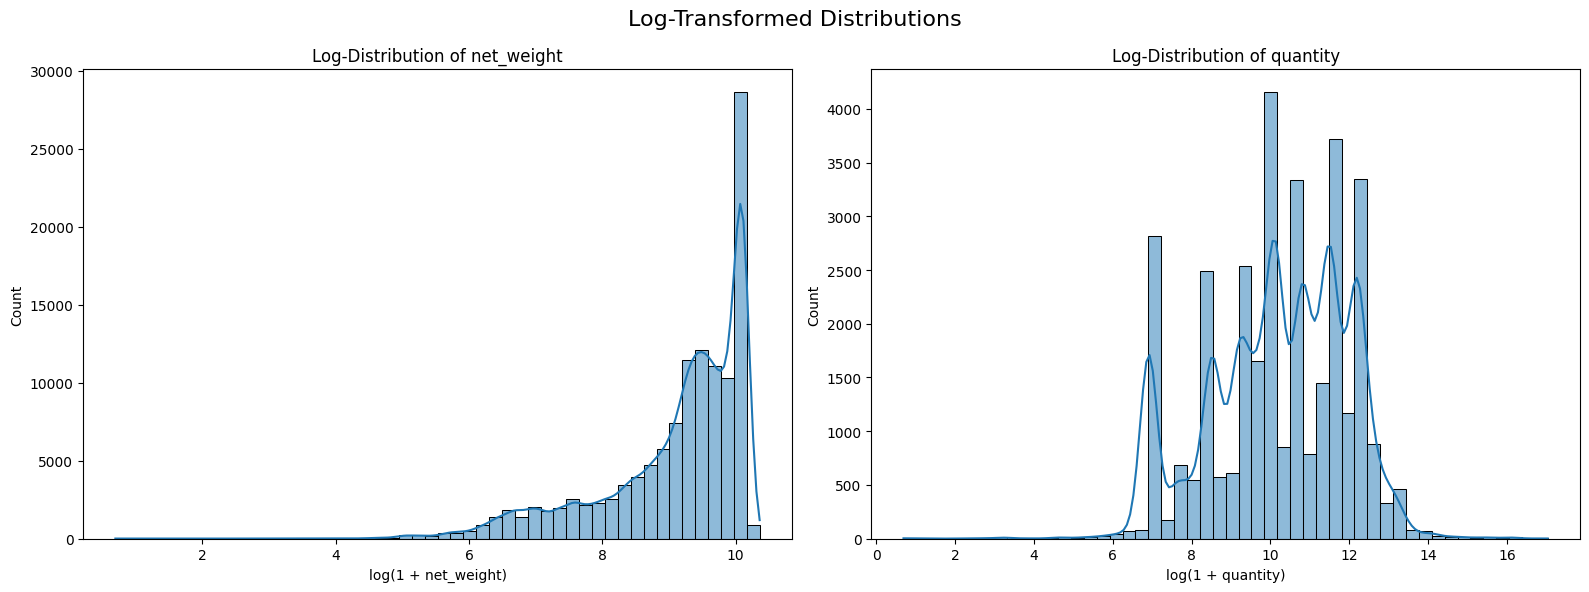

In [4]:
# --- 1. Investigating 0 or negative values ---
print("--- 1. Investigating 0 or negative values ---")
# Count problematic rows
neg_po_count = len(df_po_cleaned[df_po_cleaned['quantity'] <= 0])
neg_receivals_count = len(df_receivals_cleaned[df_receivals_cleaned['net_weight'] <= 0])

print(f"Found {neg_po_count} POs with quantity <= 0.")
print(f"Found {neg_receivals_count} receivals with net_weight <= 0.")

# --- 2. Cleaning 0/negative values ---
print("\n--- 2. Cleaning 0/negative values ---")
# Keep only rows with positive values
df_po_cleaned = df_po_cleaned[df_po_cleaned['quantity'] > 0].copy()
df_receivals_cleaned = df_receivals_cleaned[df_receivals_cleaned['net_weight'] > 0].copy()

print(f"New df_po_cleaned shape (quantity > 0): {df_po_cleaned.shape}")
print(f"New df_receivals_cleaned shape (net_weight > 0): {df_receivals_cleaned.shape}")

# --- 3. Re-splitting receivals data ---
print("\n--- 3. Re-splitting receivals data (Post-Cleaning) ---")
# We must re-create our train/validation split using the cleaned data
VALIDATION_START_DATE = pd.to_datetime('2024-08-01', utc=True)
train_receivals = df_receivals_cleaned[df_receivals_cleaned['date_arrival'] < VALIDATION_START_DATE].copy()
validation_receivals = df_receivals_cleaned[df_receivals_cleaned['date_arrival'] >= VALIDATION_START_DATE].copy()

print(f"Total cleaned receivals:  {len(df_receivals_cleaned)}")
print(f"New training receivals:       {len(train_receivals)}")
print(f"New validation receivals:     {len(validation_receivals)}")
print(f"Check: Is total == train + val?  {(len(train_receivals) + len(validation_receivals)) == len(df_receivals_cleaned)}")


# --- 4. Visualizing Distributions (Post-Cleaning) ---
print("\n--- 4. Visualizing Distributions (Post-Cleaning) ---")
# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distributions After Removing 0/Negative Values', fontsize=16)

# Plot for net_weight
sns.histplot(df_receivals_cleaned['net_weight'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Distribution of net_weight')

# Plot for quantity
sns.histplot(df_po_cleaned['quantity'], bins=50, ax=axes[1], kde=True)
axes[1].set_title('Distribution of quantity')
plt.tight_layout()
plt.savefig('distributions_cleaned.png')
print("Saved 'distributions_cleaned.png'")

# --- 5. Visualizing Log-Transformed Distributions ---
# The first plot will likely be heavily skewed. A log transform is standard.
# We use np.log1p which calculates log(1 + x) to handle any (now-gone) 0 values
print("\n--- 5. Visualizing Log-Transformed Distributions ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Log-Transformed Distributions', fontsize=16)

# Plot for log(net_weight)
sns.histplot(np.log1p(df_receivals_cleaned['net_weight']), bins=50, ax=axes[0], kde=True)
axes[0].set_title('Log-Distribution of net_weight')
axes[0].set_xlabel('log(1 + net_weight)')

# Plot for log(quantity)
sns.histplot(np.log1p(df_po_cleaned['quantity']), bins=50, ax=axes[1], kde=True)
axes[1].set_title('Log-Distribution of quantity')
axes[1].set_xlabel('log(1 + quantity)')

plt.tight_layout()
plt.savefig('log_distributions_cleaned.png')
print("Saved 'log_distributions_cleaned.png'")

print("\nEDA on anomalies and distributions complete.")

## Phase 2b: Investigating Delivery Lag

This is the most important part of our EDA. We need to know if the `delivery_date` from `purchase_orders.csv` is a reliable predictor of the `date_arrival` from `receivals.csv`.

To do this, we will:
1.  **Merge** our `train_receivals` dataframe with the `df_po_cleaned` dataframe. We will join them on `purchase_order_id` and `purchase_order_item_no`.
2.  **Create a `delivery_lag_days` feature**. This will be the difference in days between the *actual* arrival and the *expected* delivery.
3.  **Analyze and visualize** the distribution of this lag.

If the lag is consistent (e.g., "usually 2-3 days late"), we have a powerful feature. If it's random, we know this problem is much harder.

--- 1. Merging training_receivals and df_po_cleaned ---
Original train_receivals rows: 120268
New merged training DF rows: 120256
Merge complete.

--- 2. Calculating delivery lag ---
Calculated 'delivery_lag_days'.

--- 3. Statistical Summary of Lag ---
count    120256.000000
mean        -35.736021
std          98.205829
min        -723.000000
25%         -26.000000
50%         -15.000000
75%          -4.000000
max         794.000000
Name: delivery_lag_days, dtype: float64

--- 4. Visualizing Lag Distribution ---
Saved 'lag_distribution.png'

Lag analysis complete.


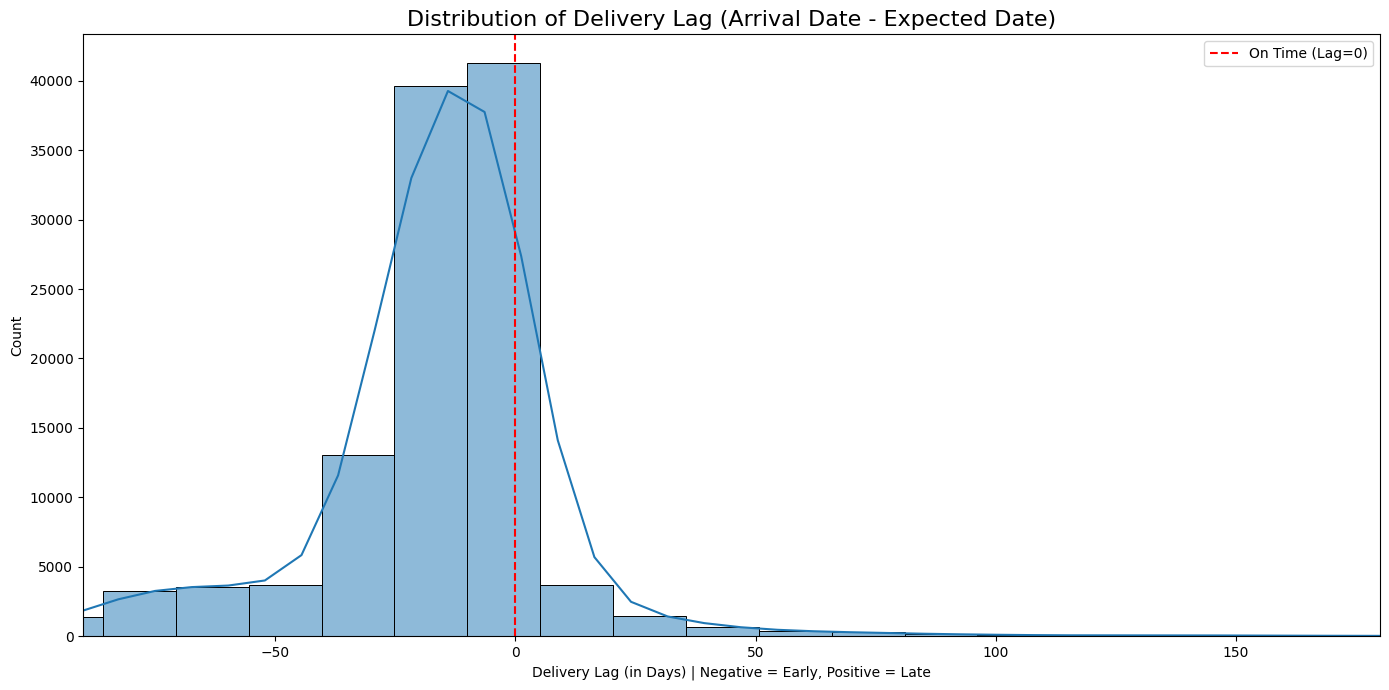

In [5]:
# --- 1. Merge Receivals and POs ---
print("--- 1. Merging training_receivals and df_po_cleaned ---")
# Define the keys to join on
merge_keys = ['purchase_order_id', 'purchase_order_item_no']

# We use an 'inner' join. This focuses our analysis on receivals
# that have a corresponding purchase order in our cleaned PO table.
# We'll use our 'train_receivals' set for this EDA.
df_train_merged = pd.merge(
    train_receivals,
    df_po_cleaned,
    on=merge_keys,
    how='inner'
)

print(f"Original train_receivals rows: {len(train_receivals)}")
print(f"New merged training DF rows: {len(df_train_merged)}")
print("Merge complete.")

# --- 2. Create 'delivery_lag_days' Feature ---
print("\n--- 2. Calculating delivery lag ---")
# Calculate the difference in days.
# (date_arrival) - (delivery_date)
# A positive number means the delivery was LATE.
# A negative number means the delivery was EARLY.
df_train_merged['delivery_lag_days'] = (df_train_merged['date_arrival'] - df_train_merged['delivery_date']).dt.days

print("Calculated 'delivery_lag_days'.")

# --- 3. Analyze the Lag ---
print("\n--- 3. Statistical Summary of Lag ---")
print(df_train_merged['delivery_lag_days'].describe())

# --- 4. Visualize the Lag ---
print("\n--- 4. Visualizing Lag Distribution ---")
plt.figure(figsize=(14, 7))

# We'll create a histogram of the lag
sns.histplot(df_train_merged['delivery_lag_days'], bins=100, kde=True)

# We'll zoom in on a "reasonable" range, e.g., 90 days early to 180 days late
# The .describe() output will tell us if this is a good range
plt.xlim(-90, 180)
plt.title('Distribution of Delivery Lag (Arrival Date - Expected Date)', fontsize=16)
plt.xlabel('Delivery Lag (in Days) | Negative = Early, Positive = Late')
plt.ylabel('Count')

# Add a vertical line at Day 0 (On Time)
plt.axvline(x=0, color='red', linestyle='--', label='On Time (Lag=0)')
plt.legend()

plt.tight_layout()
plt.savefig('lag_distribution.png')
print("Saved 'lag_distribution.png'")

print("\nLag analysis complete.")

## Phase 2c: Analyzing Lag by Supplier & Order Status

Our analysis of `delivery_lag_days` shows that deliveries are almost always *early*. This "earliness" is likely not random. Our hypothesis is that **this behavior is tied to the supplier**. Some suppliers might be very consistent (e.g., "always 14 days early"), while others are erratic.

We will also investigate the `status` column from the purchase orders. We need to confirm that `Deleted` orders *never* arrive.

Our plan:
1.  **Analyze Lag by Supplier:** Group our merged training data by `supplier_id` and calculate the `median` lag for each. (We'll use median because it's robust to the -723/+794 day outliers).
2.  **Investigate `Deleted` Orders:** Check if any `Deleted` purchase order *ever* resulted in a receival. If not, we can safely **ignore all `Deleted` orders** when making future predictions.

In [6]:
# --- 1. Analyze Lag by Supplier ---
print("--- 1. Calculating median lag per supplier ---")
# We'll use our 'df_train_merged' which contains the lag data
supplier_lag_stats = df_train_merged.groupby('supplier_id')['delivery_lag_days'].agg(
    median_lag='median',
    mean_lag='mean',
    count='count'
).sort_values(by='median_lag')

print("Supplier Lag Stats (Top 5 Earliest):")
print(supplier_lag_stats.head(5))

print("\nSupplier Lag Stats (Top 5 Latest):")
print(supplier_lag_stats.tail(5))

# Let's check suppliers with a high count, as they are more reliable
print("\nSupplier Lag Stats (Most Frequent Suppliers):")
print(supplier_lag_stats.sort_values(by='count', ascending=False).head(5))


# --- 2. Investigate 'Deleted' Orders ---
print("\n--- 2. Investigating 'Deleted' purchase orders ---")

# We need all receivals (not just training) and all POs
# We'll merge our *full* cleaned datasets
df_full_merged = pd.merge(
    df_receivals_cleaned,
    df_po_cleaned,
    on=['purchase_order_id', 'purchase_order_item_no'],
    how='inner'
)

# Now, let's group by the 'status' from the PO and see if 'Deleted' orders have any receivals
status_receival_summary = df_full_merged.groupby('status')['net_weight'].agg(
    total_weight_received='sum',
    number_of_receivals='count',
    avg_weight_received='mean'
)

print("\nSummary of Receivals by PO Status:")
print(status_receival_summary)

print("\nLag and status analysis complete.")

--- 1. Calculating median lag per supplier ---
Supplier Lag Stats (Top 5 Earliest):
             median_lag    mean_lag  count
supplier_id                               
50387            -378.5 -347.948565    836
69917            -337.0 -237.333333      3
69630            -278.0 -243.222222      9
50430            -277.0 -306.928421    475
68891            -276.0 -276.000000      1

Supplier Lag Stats (Top 5 Latest):
             median_lag    mean_lag  count
supplier_id                               
60213              21.0   24.000000      3
68536              21.0   16.800000     10
70166              34.0   79.318182     66
69730              83.0   83.000000      2
84767             109.5  108.500000      4

Supplier Lag Stats (Most Frequent Suppliers):
             median_lag   mean_lag  count
supplier_id                              
52036             -19.0 -39.370627  10663
10001              -3.0  -2.339100   8381
52064             -19.0 -29.835494   7021
69879             -18